In [1]:
# Install dependencies
!pip install -q "gymnasium[mujoco]>=1.0.0" "gymnasium-robotics>=1.3.0"
!pip install -q torch wandb imageio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.2/26.2 MB 74.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 143.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.5/852.5 kB 65.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 25.3 MB/s eta 0:00:00


In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal
from gymnasium_robotics import mamujoco_v1
import matplotlib.pyplot as plt
import wandb
import os
from collections import deque
from datetime import datetime
import math

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: NVIDIA A100-SXM4-40GB


## Environment Setup

In [3]:
# Environment setup
env = mamujoco_v1.parallel_env(
    scenario="Ant",
    agent_conf="2x4",
    agent_obsk=1,
    render_mode=None
)

agents = env.agents
num_agents = len(agents)
obs_dim = env.observation_space(agents[0]).shape[0]
action_dim = env.action_space(agents[0]).shape[0]

print(f"Agents: {num_agents} ({agents})")
print(f"Obs dim: {obs_dim}, Action dim: {action_dim}")
env.close()

Agents: 2 (['agent_0', 'agent_1'])
Obs dim: 63, Action dim: 4


## Simplified GAT Layer

**Optimizations:**
- Single projection (no separate Q/K/V)
- Simplified attention mechanism
- Minimal parameters for fast training

In [4]:
class SimpleGATLayer(nn.Module):
    """Simplified GAT with fewer parameters for faster training."""
    def __init__(self, in_dim, out_dim, num_agents, num_heads=2, dropout=0.0):
        super().__init__()
        self.num_agents = num_agents
        self.num_heads = num_heads
        self.head_dim = out_dim // num_heads
        assert out_dim % num_heads == 0

        # Single projection instead of separate Q,K,V
        self.proj = nn.Linear(in_dim, out_dim)
        self.attn = nn.Linear(out_dim, num_heads)
        self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

    def forward(self, H, adj=None):
        B, N, _ = H.shape

        # Project
        H_proj = self.proj(H)  # [B, N, out_dim]

        # Compute attention scores
        attn_scores = self.attn(H_proj)  # [B, N, num_heads]
        attn_weights = F.softmax(attn_scores, dim=1)  # Normalize over nodes

        # Apply attention (simplified: just weight and sum)
        H_out = torch.einsum('bnh,bnd->bnd', attn_weights.mean(dim=-1, keepdim=True), H_proj)

        return self.dropout(F.relu(H_out))


print("✓ Simplified GAT layer defined!")

✓ Simplified GAT layer defined!


## Enhanced GAT Policy and Value Networks

**Improvements from v7:**
- Centralized value function (global pooling)
- Conservative initial std (-0.5)
- Tanh activations for bounded outputs

In [5]:
class OptimizedGATPolicy(nn.Module):
    def __init__(self, obs_dim, action_dim, num_agents=2, hidden_dim=64, num_heads=2):
        super().__init__()
        self.num_agents = num_agents
        self.obs_dim = obs_dim
        self.action_dim = action_dim

        # Simpler encoder
        self.encoder = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.Tanh(),  # Tanh for bounded activations
        )

        # Single GAT layer (faster)
        self.gat = SimpleGATLayer(hidden_dim, hidden_dim, num_agents, num_heads)

        # Actor head
        self.actor_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.Tanh(),
            nn.Linear(hidden_dim // 2, action_dim)
        )

        # Lower initial std for more conservative exploration
        self.log_std = nn.Parameter(torch.ones(action_dim) * -0.5)

    def forward(self, obs_dict):
        agent_ids = sorted(obs_dict.keys())
        device = next(self.parameters()).device

        obs_list = []
        for aid in agent_ids:
            obs = obs_dict[aid]
            if isinstance(obs, np.ndarray):
                obs = torch.FloatTensor(obs).to(device)
            elif isinstance(obs, torch.Tensor):
                obs = obs.to(device)
            if obs.dim() == 0:
                obs = obs.unsqueeze(0)
            obs_list.append(obs)

        first_obs = obs_list[0]
        if first_obs.dim() == 1:
            obs_stacked = torch.stack(obs_list, dim=0).unsqueeze(0)
            B = 1
        else:
            obs_stacked = torch.stack(obs_list, dim=1)
            B = obs_stacked.shape[0]

        # Forward
        H = self.encoder(obs_stacked)
        H = self.gat(H)
        mu = self.actor_head(H)

        # Clamp std to reasonable range
        log_std = torch.clamp(self.log_std, -2.0, 0.5)
        std = torch.exp(log_std).unsqueeze(0).unsqueeze(0).expand_as(mu)

        mu_dict = {agent_ids[i]: mu[:, i] for i in range(self.num_agents)}
        std_dict = {agent_ids[i]: std[:, i] for i in range(self.num_agents)}

        return mu_dict, std_dict


class OptimizedGATValueNet(nn.Module):
    """Centralized value function (v7 style)"""
    def __init__(self, obs_dim, num_agents=2, hidden_dim=64, num_heads=2):
        super().__init__()
        self.num_agents = num_agents

        self.encoder = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.Tanh(),
        )

        self.gat = SimpleGATLayer(hidden_dim, hidden_dim, num_agents, num_heads)

        # Global value (centralized)
        self.value_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.Tanh(),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, obs_dict):
        agent_ids = sorted(obs_dict.keys())
        device = next(self.parameters()).device

        obs_list = []
        for aid in agent_ids:
            obs = obs_dict[aid]
            if isinstance(obs, np.ndarray):
                obs = torch.FloatTensor(obs).to(device)
            elif isinstance(obs, torch.Tensor):
                obs = obs.to(device)
            if obs.dim() == 0:
                obs = obs.unsqueeze(0)
            obs_list.append(obs)

        first_obs = obs_list[0]
        if first_obs.dim() == 1:
            obs_stacked = torch.stack(obs_list, dim=0).unsqueeze(0)
        else:
            obs_stacked = torch.stack(obs_list, dim=1)

        H = self.encoder(obs_stacked)
        H = self.gat(H)

        # Global pooling (centralized value)
        H_pool = H.mean(dim=1)
        v = self.value_head(H_pool)

        return v


print("✓ Optimized GAT networks with centralized value!")

✓ Optimized GAT networks with centralized value!


## Multi-Agent Buffer (v7 style - separate buffers)

In [6]:
class MultiAgentRolloutBuffer:
    def __init__(self, buffer_size, obs_dim, action_dim, num_agents, agent_ids, device):
        self.buffer_size = buffer_size
        self.num_agents = num_agents
        self.agent_ids = agent_ids
        self.device = device

        self.buffers = {}
        for agent_id in agent_ids:
            self.buffers[agent_id] = {
                'observations': torch.zeros((buffer_size, obs_dim), dtype=torch.float32),
                'actions': torch.zeros((buffer_size, action_dim), dtype=torch.float32),
                'logprobs': torch.zeros(buffer_size, dtype=torch.float32),
                'values': torch.zeros(buffer_size, dtype=torch.float32),
                'rewards': torch.zeros(buffer_size, dtype=torch.float32),
                'dones': torch.zeros(buffer_size, dtype=torch.float32),
                'advantages': torch.zeros(buffer_size, dtype=torch.float32),
                'returns': torch.zeros(buffer_size, dtype=torch.float32)
            }

        self.ptr = 0

    def add(self, obs_dict, action_dict, logprob_dict, value_dict, reward_dict, done_dict):
        for agent_id in self.agent_ids:
            self.buffers[agent_id]['observations'][self.ptr] = torch.FloatTensor(obs_dict[agent_id])
            self.buffers[agent_id]['actions'][self.ptr] = torch.FloatTensor(action_dict[agent_id])
            self.buffers[agent_id]['logprobs'][self.ptr] = logprob_dict[agent_id]
            self.buffers[agent_id]['values'][self.ptr] = value_dict[agent_id]
            self.buffers[agent_id]['rewards'][self.ptr] = reward_dict[agent_id]
            self.buffers[agent_id]['dones'][self.ptr] = float(done_dict[agent_id])

        self.ptr += 1

    def compute_advantages(self, gamma=0.99, lam=0.95):
        for agent_id in self.agent_ids:
            buf = self.buffers[agent_id]
            last_adv = 0.0
            last_value = 0.0

            for t in reversed(range(self.ptr)):
                mask = 1.0 - buf['dones'][t]
                delta = buf['rewards'][t] + gamma * last_value * mask - buf['values'][t]
                last_adv = delta + gamma * lam * mask * last_adv
                buf['advantages'][t] = last_adv
                last_value = buf['values'][t].item()

            buf['returns'][:self.ptr] = buf['advantages'][:self.ptr] + buf['values'][:self.ptr]

    def get_batches(self, batch_size):
        indices = torch.randperm(self.ptr)

        for start_idx in range(0, self.ptr, batch_size):
            end_idx = min(start_idx + batch_size, self.ptr)
            batch_indices = indices[start_idx:end_idx]

            batch = {}
            for agent_id in self.agent_ids:
                buf = self.buffers[agent_id]
                batch[agent_id] = {
                    'observations': buf['observations'][batch_indices].to(self.device),
                    'actions': buf['actions'][batch_indices].to(self.device),
                    'old_logprobs': buf['logprobs'][batch_indices].to(self.device),
                    'advantages': buf['advantages'][batch_indices].to(self.device),
                    'returns': buf['returns'][batch_indices].to(self.device)
                }

            yield batch

    def reset(self):
        self.ptr = 0


print("✓ Buffer ready!")

✓ Buffer ready!


## PPO Loss (v7 style - centralized value)

In [7]:
def compute_multi_agent_ppo_loss(policy, value_net, batch, agent_ids,
                                  eps_clip=0.2, value_coef=1.0, entropy_coef=0.005):
    obs_dict = {aid: batch[aid]['observations'] for aid in agent_ids}

    mu_dict, std_dict = policy(obs_dict)

    total_actor_loss = 0.0
    total_value_loss = 0.0
    total_entropy = 0.0
    total_ratio_mean = 0.0

    for agent_id in agent_ids:
        agent_batch = batch[agent_id]

        mu = mu_dict[agent_id]
        std = std_dict[agent_id]
        dist = Normal(mu, std)

        actions = agent_batch['actions']
        old_logprobs = agent_batch['old_logprobs']
        advantages = agent_batch['advantages']
        returns = agent_batch['returns']

        # Normalize advantages
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        new_logprobs = dist.log_prob(actions).sum(dim=-1)
        entropy = dist.entropy().sum(dim=-1)

        # PPO clipped objective
        ratio = torch.exp(new_logprobs - old_logprobs)
        surr1 = ratio * advantages
        surr2 = torch.clamp(ratio, 1.0 - eps_clip, 1.0 + eps_clip) * advantages
        actor_loss = -torch.min(surr1, surr2).mean()

        total_actor_loss += actor_loss
        total_entropy += entropy.mean()
        total_ratio_mean += ratio.mean().item()

    # Centralized value loss
    value_pred = value_net(obs_dict).squeeze(-1)
    # Average returns across agents for centralized value
    avg_returns = torch.stack([batch[aid]['returns'] for aid in agent_ids]).mean(dim=0)
    value_loss = F.mse_loss(value_pred, avg_returns)

    num_agents = len(agent_ids)
    total_actor_loss /= num_agents
    total_entropy /= num_agents
    total_ratio_mean /= num_agents

    total_loss = total_actor_loss + value_coef * value_loss - entropy_coef * total_entropy

    loss_info = {
        'total_loss': total_loss.item(),
        'actor_loss': total_actor_loss.item(),
        'value_loss': value_loss.item(),
        'entropy': total_entropy.item(),
        'ratio_mean': total_ratio_mean
    }

    return total_loss, loss_info


print("✓ PPO loss with centralized value ready!")

✓ PPO loss with centralized value ready!


## Fine-tuned Configuration (v8)

**Key Changes from gat_optimized:**
- `num_updates`: 200 → **300** (+50% training)
- `K_epochs`: 5 → **4** (from v7, better stability)
- `value_coef`: 1.0 (prioritize value learning)
- `entropy_coef`: 0.005 (faster convergence)
- Centralized value function

In [8]:
config = {
    'scenario': 'Ant',
    'agent_conf': '2x4',
    'agent_obsk': 1,

    # Network (same as optimized)
    'hidden_dim': 64,
    'num_heads': 2,
    'dropout': 0.0,

    # PPO (fine-tuned)
    'horizon_T': 2048,
    'K_epochs': 4,         # From v7 (was 5)
    'batch_size': 256,
    'gamma': 0.99,
    'lam': 0.95,
    'eps_clip': 0.2,
    'lr': 3e-4,
    'value_coef': 1.0,     # From v7 (was 0.5)
    'entropy_coef': 0.005, # From v7 (was 0.01)
    'max_grad_norm': 0.5,
    'num_updates': 300,    # EXTENDED from 200

    # Reward preprocessing
    'reward_clip': None,
    'reward_scale': 0.1,

    'log_interval': 5,
    'save_interval': 50,
    'device': str(device)
}

wandb.init(
    project="gnn-long",
    name=f"gat-v8-{datetime.now().strftime('%m%d-%H%M')}",
    config=config,
    mode="online"
)

print("Fine-tuned Configuration (v8):")
print(f"  Network: {config['hidden_dim']}D hidden, {config['num_heads']} heads")
print(f"  Training: {config['num_updates']} updates × {config['horizon_T']} steps")
print(f"  Total steps: {config['num_updates'] * config['horizon_T']:,}")
print(f"  Unified LR: {config['lr']}")
print(f"  Reward scale: {config['reward_scale']} (NO clipping)")
print(f"  Value coef: {config['value_coef']} (increased)")
print(f"  Entropy coef: {config['entropy_coef']} (decreased)")
print(f"  K epochs: {config['K_epochs']} (optimized)")
print(f"\nTarget time: ~75-90 min on A100")
print(f"\nKey improvements:")
print(f"  ✓ Extended training (200 → 300 updates)")
print(f"  ✓ Centralized value function (v7 style)")
print(f"  ✓ Optimized PPO coefficients")
print(f"  ✓ Conservative exploration + cosine annealing")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: chenwc (chenwc-national-taiwan-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Fine-tuned Configuration (v8):
  Network: 64D hidden, 2 heads
  Training: 300 updates × 2048 steps
  Total steps: 614,400
  Unified LR: 0.0003
  Reward scale: 0.1 (NO clipping)
  Value coef: 1.0 (increased)
  Entropy coef: 0.005 (decreased)
  K epochs: 4 (optimized)

Target time: ~75-90 min on A100

Key improvements:
  ✓ Extended training (200 → 300 updates)
  ✓ Centralized value function (v7 style)
  ✓ Optimized PPO coefficients
  ✓ Conservative exploration + cosine annealing


## Initialize Networks

In [9]:
env = mamujoco_v1.parallel_env(
    scenario=config['scenario'],
    agent_conf=config['agent_conf'],
    agent_obsk=config['agent_obsk'],
    render_mode=None
)

agents = env.agents
num_agents = len(agents)
obs_dim = env.observation_space(agents[0]).shape[0]
action_dim = env.action_space(agents[0]).shape[0]

policy = OptimizedGATPolicy(
    obs_dim, action_dim,
    num_agents=num_agents,
    hidden_dim=config['hidden_dim'],
    num_heads=config['num_heads']
).to(device)

value_net = OptimizedGATValueNet(
    obs_dim,
    num_agents=num_agents,
    hidden_dim=config['hidden_dim'],
    num_heads=config['num_heads']
).to(device)

# UNIFIED optimizer (key fix!)
all_params = list(policy.parameters()) + list(value_net.parameters())
optimizer = torch.optim.Adam(all_params, lr=config['lr'])

# Cosine annealing (extended for 300 updates)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=config['num_updates'], eta_min=1e-5
)

buffer = MultiAgentRolloutBuffer(
    config['horizon_T'], obs_dim, action_dim,
    num_agents, agents, device
)

os.makedirs("checkpoints_v8", exist_ok=True)

print(f"\nPolicy parameters: {sum(p.numel() for p in policy.parameters()):,}")
print(f"Value parameters: {sum(p.numel() for p in value_net.parameters()):,}")
print(f"Total: {sum(p.numel() for p in all_params):,}")
print(f"\n✓ Using UNIFIED optimizer with cosine annealing")


Policy parameters: 10,602
Value parameters: 10,499
Total: 21,101

✓ Using UNIFIED optimizer with cosine annealing


## Training Loop (Extended to 300 Updates)

In [10]:
episode_rewards = {aid: [] for aid in agents}
update_rewards = []
reward_windows = {aid: deque(maxlen=10) for aid in agents}

print(f"\n{'='*70}")
print(f"Starting Fine-tuned Training (v8): {config['num_updates']} updates")
print(f"{'='*70}\n")

for update_idx in range(config['num_updates']):
    buffer.reset()
    obs_dict, _ = env.reset()

    episode_reward_dict = {aid: 0.0 for aid in agents}
    episode_count = 0

    # Rollout collection
    for step in range(config['horizon_T']):
        with torch.no_grad():
            mu_dict, std_dict = policy(obs_dict)

            action_dict = {}
            logprob_dict = {}

            for agent_id in agents:
                dist = Normal(mu_dict[agent_id], std_dict[agent_id])
                action = dist.sample()
                logprob = dist.log_prob(action).sum(dim=-1)

                action_dict[agent_id] = action.squeeze(0).cpu().numpy()
                logprob_dict[agent_id] = logprob.item()

            # Centralized value
            value = value_net(obs_dict).squeeze(-1).item()
            value_dict = {aid: value for aid in agents}

        next_obs_dict, reward_dict, term_dict, trunc_dict, info_dict = env.step(action_dict)
        done_dict = {aid: term_dict[aid] or trunc_dict[aid] for aid in agents}

        # Mild reward scaling only
        reward_dict_scaled = {
            aid: reward_dict[aid] * config['reward_scale']
            for aid in agents
        }

        buffer.add(obs_dict, action_dict, logprob_dict, value_dict, reward_dict_scaled, done_dict)

        for aid in agents:
            episode_reward_dict[aid] += reward_dict[aid]  # Track unscaled

        obs_dict = next_obs_dict

        if any(done_dict.values()):
            for aid in agents:
                episode_rewards[aid].append(episode_reward_dict[aid])
                reward_windows[aid].append(episode_reward_dict[aid])
            episode_count += 1
            episode_reward_dict = {aid: 0.0 for aid in agents}
            obs_dict, _ = env.reset()

    # Policy update
    buffer.compute_advantages(gamma=config['gamma'], lam=config['lam'])

    epoch_losses = []
    for epoch in range(config['K_epochs']):
        batch_losses = []

        for batch in buffer.get_batches(config['batch_size']):
            loss, loss_info = compute_multi_agent_ppo_loss(
                policy, value_net, batch, agents,
                eps_clip=config['eps_clip'],
                value_coef=config['value_coef'],
                entropy_coef=config['entropy_coef']
            )

            optimizer.zero_grad()
            loss.backward()

            torch.nn.utils.clip_grad_norm_(all_params, max_norm=config['max_grad_norm'])

            optimizer.step()

            batch_losses.append(loss_info)

        if batch_losses:
            epoch_loss = {k: np.mean([d[k] for d in batch_losses]) for k in batch_losses[0].keys()}
            epoch_losses.append(epoch_loss)

    scheduler.step()

    # Logging
    if episode_count > 0:
        recent_rewards = [episode_rewards[aid][-episode_count:] for aid in agents
                          if len(episode_rewards[aid]) >= episode_count]
        avg_reward = np.mean([np.mean(r) for r in recent_rewards]) if recent_rewards else 0.0
    else:
        avg_reward = 0.0

    update_rewards.append(avg_reward)

    log_dict = {
        'update': update_idx + 1,
        'avg_reward': avg_reward,
        'episode_count': episode_count,
        'lr': scheduler.get_last_lr()[0]
    }

    for aid in agents:
        if len(reward_windows[aid]) > 0:
            log_dict[f'reward_{aid}'] = np.mean(reward_windows[aid])

    if epoch_losses:
        final_loss = epoch_losses[-1]
        log_dict.update(final_loss)

    wandb.log(log_dict)

    # Console logging
    if (update_idx + 1) % config['log_interval'] == 0:
        window_avg = np.mean([np.mean(reward_windows[aid]) for aid in agents
                              if len(reward_windows[aid]) > 0])
        if epoch_losses:
            print(f"Update {update_idx+1:3d}/{config['num_updates']} | "
                  f"Eps: {episode_count:2d} | "
                  f"Reward: {avg_reward:7.1f} | "
                  f"R(10): {window_avg:7.1f} | "
                  f"Loss: {final_loss['total_loss']:7.3f} | "
                  f"V-Loss: {final_loss['value_loss']:6.3f} | "
                  f"Ent: {final_loss['entropy']:.3f} | "
                  f"Ratio: {final_loss['ratio_mean']:.3f}")
        else:
            print(f"Update {update_idx+1:3d}/{config['num_updates']} | Eps: {episode_count:2d} | Reward: {avg_reward:7.1f}")

    # Save checkpoint
    if (update_idx + 1) % config['save_interval'] == 0:
        checkpoint = {
            'update': update_idx + 1,
            'policy_state_dict': policy.state_dict(),
            'value_net_state_dict': value_net.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'config': config
        }
        torch.save(checkpoint, f"checkpoints_v8/checkpoint_update_{update_idx+1}.pt")
        print(f"  └─ Checkpoint saved")

env.close()

torch.save({
    'policy_state_dict': policy.state_dict(),
    'value_net_state_dict': value_net.state_dict(),
    'config': config
}, "checkpoints_v8/final_model_v8.pt")

print(f"\n{'='*70}")
print("Training Complete (v8)!")
print(f"Total episodes: {sum(len(episode_rewards[aid]) for aid in agents)}")
window_avg = np.mean([np.mean(list(reward_windows[aid])) for aid in agents
                      if len(reward_windows[aid]) > 0])
print(f"Final avg reward: {window_avg:.1f}")
best_episode = max([max(episode_rewards[aid]) if len(episode_rewards[aid]) > 0 else -1000 for aid in agents])
print(f"Best episode: {best_episode:.1f}")
print(f"{'='*70}")

wandb.finish()


Starting Fine-tuned Training (v8): 300 updates

Update   5/300 | Eps:  8 | Reward:  -115.5 | R(10):   -97.9 | Loss:   0.394 | V-Loss:  0.419 | Ent: 3.541 | Ratio: 0.999
Update  10/300 | Eps:  6 | Reward:   -93.9 | R(10):  -110.0 | Loss:   0.521 | V-Loss:  0.548 | Ent: 3.384 | Ratio: 1.000
Update  15/300 | Eps: 16 | Reward:   -28.5 | R(10):   -32.0 | Loss:   0.683 | V-Loss:  0.707 | Ent: 3.271 | Ratio: 1.002
Update  20/300 | Eps: 14 | Reward:   -37.4 | R(10):   -41.9 | Loss:   0.362 | V-Loss:  0.389 | Ent: 3.186 | Ratio: 0.998
Update  25/300 | Eps:  3 | Reward:   -46.8 | R(10):   -53.0 | Loss:   0.154 | V-Loss:  0.182 | Ent: 3.061 | Ratio: 1.001
Update  30/300 | Eps:  8 | Reward:     1.1 | R(10):   -10.1 | Loss:   0.239 | V-Loss:  0.266 | Ent: 2.953 | Ratio: 1.000
Update  35/300 | Eps:  8 | Reward:   -13.8 | R(10):   -13.2 | Loss:   0.382 | V-Loss:  0.407 | Ent: 2.857 | Ratio: 1.000
Update  40/300 | Eps:  9 | Reward:     8.5 | R(10):    14.3 | Loss:   0.310 | V-Loss:  0.333 | Ent: 2.75

actor_loss,▅▄▂▅▁▁▂▄▁▁▁▄▃▃▃▄▄▄▄▄▄▅▅▅▆▅▅▄▆▅▇█▇▇▇█████
avg_reward,▁▁▁▂▂▂▂▃▃▂▄▃▅▃▄▄▅▆▆▄▄▆▅▅▄▅▇▅▅▄▄▆▃▄▅▆▅█▆▅
entropy,█████▇▇▆▆▆▅▅▄▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
episode_count,▃▇█▅▅▂▆▄▂▆▂▂▃▁▂▂▁▁▁▂▁▁▁▁▂▁▁▁▂▁▁▄▁▂▁▂▂▂▃▁
lr,██████████▇▇▆▆▆▆▆▆▅▅▅▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁
ratio_mean,▂▄▆▄▄▃▁▅▃▁▃▄▅▃▂▃▄▃█▄▂▄▄▆▅▄▆▄▄▄▅▃▄▃▅▄▄▄▄▄
reward_agent_0,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▅▅▆▅▇▆▆▅▆▆▇▆▇▇██▇█▇▇▇▇▆▆▇█
reward_agent_1,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▂▃▃▄▄▅▄▅▅▆▅▇▇▇▇▆▆▅▇▆▆▇▆█▇▆
total_loss,▃▄▃▁▂▁▄▂▃▂▂▂▄▃▂▂▁▂▄▃▅▃▅▄▅▄▄▄▅▃▅▅▅▅█▃▄▆▅▅
update,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇█████
+1,...


## Visualization

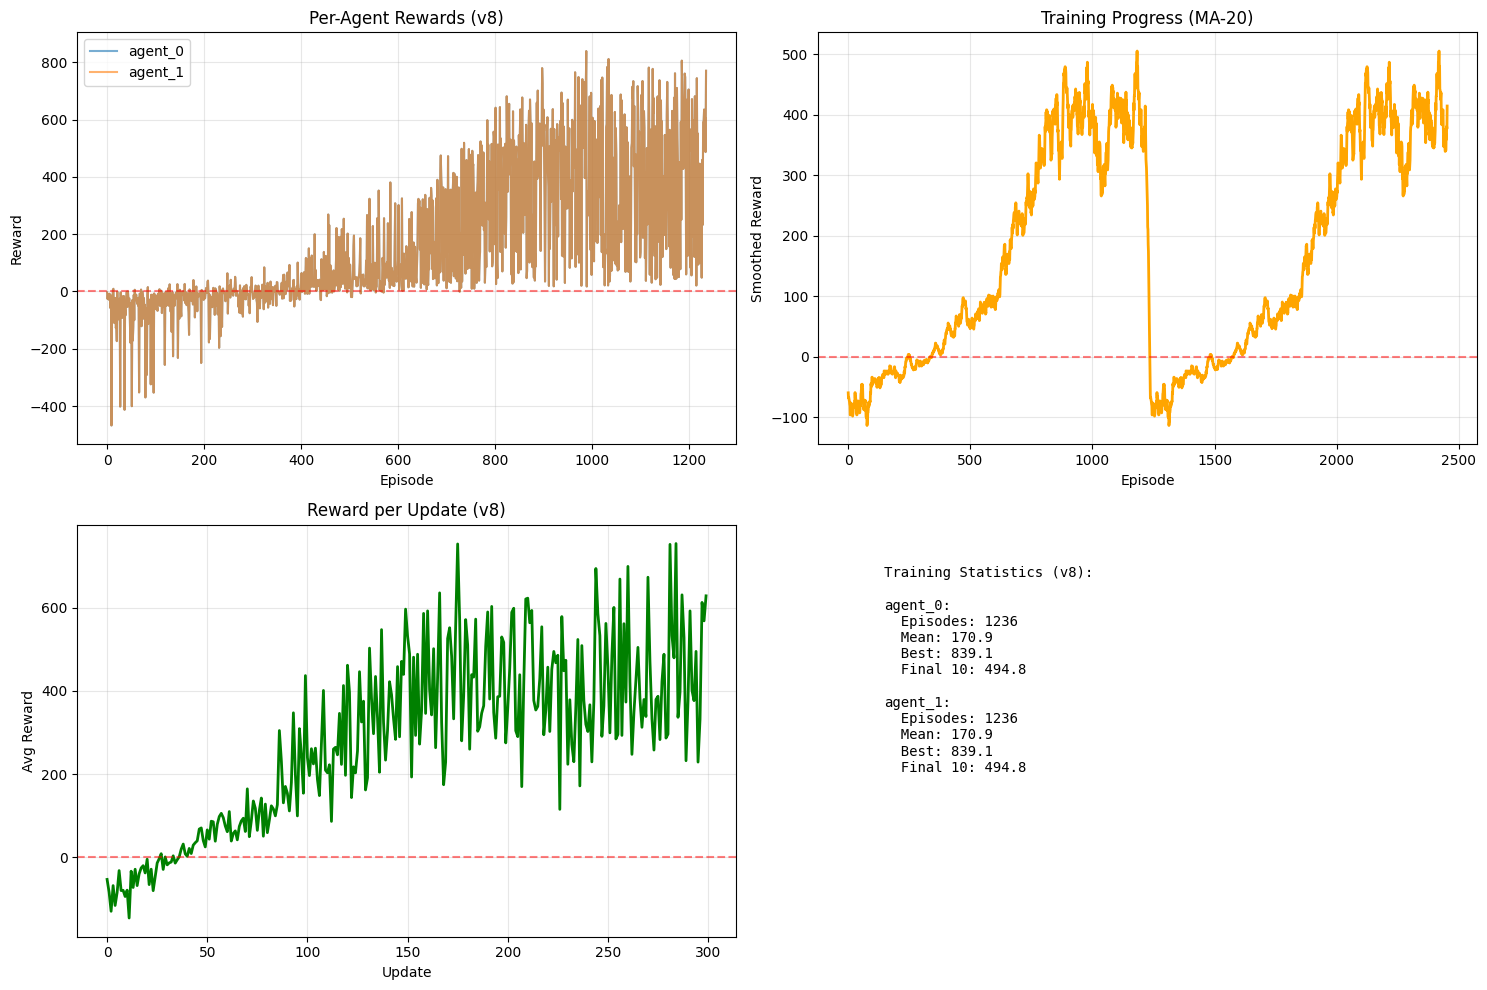


v8 Key Features:
  ✓ Extended training: 300 updates (614K steps)
  ✓ Centralized value function (v7 style)
  ✓ Optimized PPO (K=4, value_coef=1.0, entropy=0.005)
  ✓ Unified optimizer + cosine annealing
  ✓ Conservative exploration (log_std=-0.5)


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Per-agent rewards
axes[0, 0].set_title("Per-Agent Rewards (v8)")
for aid in agents:
    if len(episode_rewards[aid]) > 0:
        axes[0, 0].plot(episode_rewards[aid], alpha=0.6, label=aid)
axes[0, 0].set_xlabel("Episode")
axes[0, 0].set_ylabel("Reward")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axhline(y=0, color='r', linestyle='--', alpha=0.5, label='Zero')

# Plot 2: Smoothed
all_rewards = [r for aid in agents for r in episode_rewards[aid]]
if len(all_rewards) >= 20:
    window = 20
    smoothed = np.convolve(all_rewards, np.ones(window)/window, mode='valid')
    axes[0, 1].plot(smoothed, linewidth=2, color='orange')
    axes[0, 1].set_xlabel("Episode")
    axes[0, 1].set_ylabel("Smoothed Reward")
    axes[0, 1].set_title(f"Training Progress (MA-{window})")
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].axhline(y=0, color='r', linestyle='--', alpha=0.5)

# Plot 3: Update-level
axes[1, 0].plot(update_rewards, linewidth=2, color='green')
axes[1, 0].set_xlabel("Update")
axes[1, 0].set_ylabel("Avg Reward")
axes[1, 0].set_title("Reward per Update (v8)")
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axhline(y=0, color='r', linestyle='--', alpha=0.5)

# Plot 4: Final stats
axes[1, 1].axis('off')
stats_text = "Training Statistics (v8):\n\n"
for aid in agents:
    if len(episode_rewards[aid]) > 0:
        stats_text += f"{aid}:\n"
        stats_text += f"  Episodes: {len(episode_rewards[aid])}\n"
        stats_text += f"  Mean: {np.mean(episode_rewards[aid]):.1f}\n"
        stats_text += f"  Best: {max(episode_rewards[aid]):.1f}\n"
        stats_text += f"  Final 10: {np.mean(list(reward_windows[aid])):.1f}\n\n"
axes[1, 1].text(0.1, 0.9, stats_text, transform=axes[1, 1].transAxes,
                fontsize=10, verticalalignment='top', family='monospace')

plt.tight_layout()
plt.show()

print(f"\n{'='*70}")
print("v8 Key Features:")
print("  ✓ Extended training: 300 updates (614K steps)")
print("  ✓ Centralized value function (v7 style)")
print("  ✓ Optimized PPO (K=4, value_coef=1.0, entropy=0.005)")
print("  ✓ Unified optimizer + cosine annealing")
print("  ✓ Conservative exploration (log_std=-0.5)")
print(f"{'='*70}")

## Evaluation


Evaluation Results (v8) - 1000 steps:
  Average: 1144.0


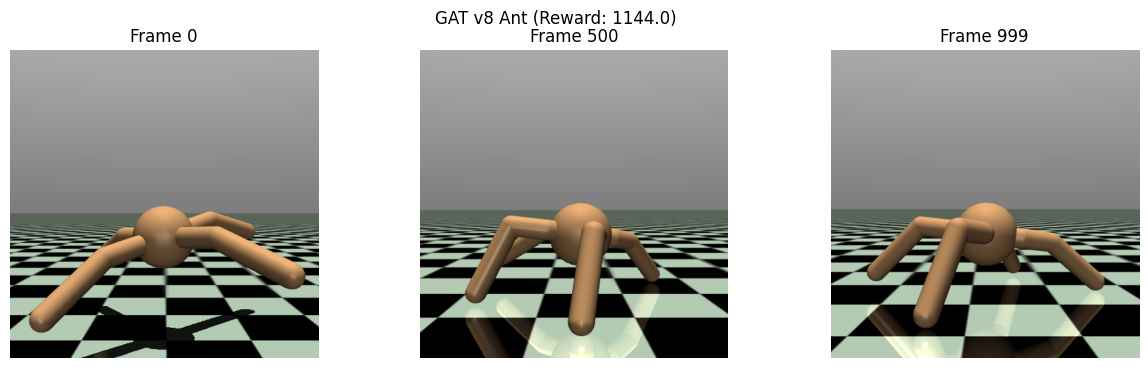

In [12]:
import os
os.environ["MUJOCO_GL"] = "egl"

eval_env = mamujoco_v1.parallel_env(
    scenario=config['scenario'],
    agent_conf=config['agent_conf'],
    agent_obsk=config['agent_obsk'],
    render_mode="rgb_array"
)

policy.eval()
obs_dict, _ = eval_env.reset()

frames = []
total_reward_dict = {aid: 0.0 for aid in eval_env.agents}

MAX_STEPS = 1000
for t in range(MAX_STEPS):
    with torch.no_grad():
        mu_dict, std_dict = policy(obs_dict)
        action_dict = {aid: mu_dict[aid].squeeze(0).cpu().numpy() for aid in eval_env.agents}

    obs_dict, reward_dict, term_dict, trunc_dict, _ = eval_env.step(action_dict)

    for aid in eval_env.agents:
        total_reward_dict[aid] += reward_dict[aid]

    frame = eval_env.render()
    frames.append(frame)

    if any(term_dict.values()) or any(trunc_dict.values()):
        break

eval_env.close()

print(f"\nEvaluation Results (v8) - {t+1} steps:")
for aid in eval_env.agents:
    print(f"  {aid}: {total_reward_dict[aid]:.1f}")
print(f"  Average: {np.mean(list(total_reward_dict.values())):.1f}")

if len(frames) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for i, idx in enumerate([0, len(frames)//2, len(frames)-1]):
        axes[i].imshow(frames[idx])
        axes[i].axis("off")
        axes[i].set_title(f"Frame {idx}")
    plt.suptitle(f"GAT v8 Ant (Reward: {np.mean(list(total_reward_dict.values())):.1f})")
    plt.show()

In [13]:
# Save GIF
try:
    import imageio
    gif_path = "gat_v8_ant.gif"
    imageio.mimsave(gif_path, frames[::2], fps=20)
    print(f"Saved: {gif_path}")
except:
    print("Install imageio: pip install imageio")

Saved: gat_v8_ant.gif
